In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings

In [ ]:
!pip install stable_baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [ ]:
!pip install shimmy

In [ ]:
import gym
from gym import spaces
import os
from datetime import datetime, timedelta
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback

In [ ]:
import json
import pickle
from sklearn.model_selection import ParameterGrid
from scipy.stats import norm
import time

In [ ]:
# Configure environment
warnings.filterwarnings('ignore')  # Suppress warnings
plt.style.use('fivethirtyeight')  # Set a nice style for plots
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 20)       # Limit displayed rows

Starting Phase 1: Environment Setup and Data Collection

In [ ]:
ticker_list = pd.read_csv('/content/drive/MyDrive/Capstone Project/TSX stocks.csv')

In [ ]:
ticker_list = ticker_list['Symbol'].to_list()

In [ ]:
# Define a sample list of 15 diverse stocks across different sectors
sample_stocks = [
    'AAPL',   # Technology - Apple
    'MSFT',   # Technology - Microsoft
    'GOOGL',  # Technology - Alphabet
    'AMZN',   # Consumer Discretionary - Amazon
    'JPM',    # Financial - JPMorgan
    'JNJ',    # Healthcare - Johnson & Johnson
    'PG',     # Consumer Staples - Procter & Gamble
    'XOM',    # Energy - Exxon Mobil
    'DIS',    # Communication Services - Disney
    'BA',     # Industrials - Boeing
    'NVDA',   # Technology - NVIDIA
    'V',      # Financial - Visa
    'WMT',    # Consumer Staples - Walmart
    'HD',     # Consumer Discretionary - Home Depot
    'VZ'      # Communication Services - Verizon
]

In [ ]:
# Function to download stock data for a given ticker list
def download_stock_data(tickers, period='15y', interval='1d'):
    """
    Download stock data for a list of tickers.

    Parameters:
    tickers (list): List of stock ticker symbols
    period (str): Time period to download (default: '5y' for 5 years)
    interval (str): Time interval between data points (default: '1d' for daily)

    Returns:
    dict: Dictionary with ticker symbols as keys and pandas DataFrames as values
    """
    print(f"Downloading data for {len(tickers)} stocks...")

    # Calculate the start and end dates
    end_date = datetime.now()
    start_date = end_date - timedelta(days=int(period[:-1])*365)  # Approximately 5 years

    # Download data for each ticker
    stock_data = {}

    for ticker in tickers:
        try:
            # Download the data
            data = yf.download(
                ticker,
                start=start_date.strftime('%Y-%m-%d'),
                end=end_date.strftime('%Y-%m-%d'),
                interval=interval,
                progress=False  # Disable progress bar for cleaner output
            )
            time.sleep(1)

            # Check if data was retrieved successfully
            if len(data) > 0:
                # Fix the MultiIndex issue by checking and flattening if needed
                if isinstance(data.columns, pd.MultiIndex):
                    # Get the column names (Open, High, Low, etc.) regardless of index structure
                    if 'Open' in data.columns.get_level_values(0):
                        data.columns = data.columns.get_level_values(0)
                    else:
                        data.columns = data.columns.get_level_values(1)

                stock_data[ticker] = data
                print(f"✓ Downloaded {ticker}: {len(data)} rows from {data.index.min().date()} to {data.index.max().date()}")
            else:
                print(f"✗ No data available for {ticker}")

        except Exception as e:
            print(f"✗ Error downloading {ticker}: {str(e)}")

    print(f"Successfully downloaded data for {len(stock_data)}/{len(tickers)} stocks.")
    return stock_data

In [ ]:
# Download data for the sample stocks
stock_data = download_stock_data(ticker_list)

YF.download() has changed argument auto_adjust default to True
✓ Downloaded AAB.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded AAUC.TO: 393 rows from 2023-09-13 to 2025-04-04
✓ Downloaded AAV.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded ABX.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded AC.TO: 3759 rows from 2010-04-12 to 2025-04-04
✓ Downloaded ACAA.TO: 188 rows from 2024-07-08 to 2025-04-04
✓ Downloaded ACB.TO: 2133 rows from 2016-10-05 to 2025-04-04
✓ Downloaded ACD.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded ACQ.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded ACX.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded ADCO.TO: 1470 rows from 2019-05-29 to 2025-04-04
✓ Downloaded ADEN.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded ADIV.TO: 251 rows from 2024-04-08 to 2025-04-04
✓ Downloaded ADN.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded AEG.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded AEM.TO: 

ERROR:yfinance:Could not get exchangeTimezoneName for ticker 'CDZ.TO' reason: 'chart'
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CDZ.TO']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-04-11 -> 2025-04-07)')


✗ No data available for CDZ.TO
✓ Downloaded CEF.TO: 1811 rows from 2018-01-18 to 2025-04-04
✓ Downloaded CEMI.TO: 890 rows from 2021-09-20 to 2025-04-04
✓ Downloaded CEMX.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CEQT.TO: 474 rows from 2023-05-17 to 2025-04-04
✓ Downloaded CEU.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CEW.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CF.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CFF.TO: 3719 rows from 2010-06-08 to 2025-04-04
✓ Downloaded CFLX.TO: 1302 rows from 2020-01-29 to 2025-04-04
✓ Downloaded CFP.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CFRT.TO: 745 rows from 2022-04-19 to 2025-04-04
✓ Downloaded CFW.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CFX.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CG.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CGAA.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CGBI.TO: 320 rows from 2023-12-28 to 202

ERROR:yfinance:404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/COG.TO?modules=financialData%2CquoteType%2CdefaultKeyStatistics%2CassetProfile%2CsummaryDetail&corsDomain=finance.yahoo.com&formatted=false&symbol=COG.TO&crumb=bzt433hMSFc
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['COG.TO']: AttributeError("'NoneType' object has no attribute 'update'")


✗ No data available for COG.TO
✓ Downloaded COMM.TO: 1735 rows from 2018-05-08 to 2025-04-04
✓ Downloaded COPP.TO: 725 rows from 2022-05-17 to 2025-04-04
✓ Downloaded COPR.TO: 163 rows from 2024-08-13 to 2025-04-04
✓ Downloaded CORE.TO: 159 rows from 2024-08-19 to 2025-04-04
✓ Downloaded COW.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CP.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CPD.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CPH.TO: 3760 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CPLS.TO: 1109 rows from 2020-11-04 to 2025-04-04
✓ Downloaded CPX.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CRDL.TO: 1578 rows from 2018-12-20 to 2025-04-04
✓ Downloaded CRED.TO: 1303 rows from 2020-01-28 to 2025-04-04
✓ Downloaded CRON.TO: 2582 rows from 2014-12-17 to 2025-04-04
✓ Downloaded CROP.TO: 883 rows from 2021-09-29 to 2025-04-04
✓ Downloaded CRP.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded CRRX.TO: 3761 rows from 2010-04-12 to

...

✗ No data available for LAAC.TO
✓ Downloaded LABS.TO: 1530 rows from 2019-03-04 to 2025-04-04
✓ Downloaded LAC.TO: 376 rows from 2023-10-06 to 2025-04-04
✓ Downloaded LAM.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded LB.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded LBS.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded LCFS.TO: 915 rows from 2021-08-13 to 2025-04-04
✓ Downloaded LCS.TO: 3757 rows from 2010-04-12 to 2025-04-04
✓ Downloaded LEAD.TO: 1145 rows from 2020-09-14 to 2025-04-04
✓ Downloaded LFE.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded LGD.TO: 3299 rows from 2012-02-13 to 2025-04-04
✓ Downloaded LGO.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded LIF.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded LIFE.TO: 1818 rows from 2018-01-09 to 2025-04-04
✓ Downloaded LIRC.TO: 522 rows from 2023-03-09 to 2025-04-04
✓ Downloaded LLHE.TO: 156 rows from 2024-08-22 to 2025-04-04
✓ Downloaded LLYH.TO: 157 rows from 2024-08-21 to 20

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['NAN.TO']: YFTzMissingError('possibly delisted; no timezone found')


✗ No data available for nan.TO
✓ Downloaded NALT.TO: 1545 rows from 2019-02-08 to 2025-04-04
✓ Downloaded NANO.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded NCF.TO: 3174 rows from 2012-08-13 to 2025-04-04
✓ Downloaded NDIV.TO: 1046 rows from 2021-01-28 to 2025-04-04
✓ Downloaded NDM.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded NEO.TO: 1837 rows from 2017-12-08 to 2025-04-04
✓ Downloaded NEXT.TO: 3313 rows from 2012-01-24 to 2025-04-04
✓ Downloaded NFI.TO: 3313 rows from 2012-01-24 to 2025-04-04
✓ Downloaded NG.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded NGD.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded NGDN.TO: 53 rows from 2024-12-02 to 2025-04-04
✓ Downloaded NGEX.TO: 1413 rows from 2019-08-20 to 2025-04-04
✓ Downloaded NGPE.TO: 1278 rows from 2020-03-04 to 2025-04-04
✓ Downloaded NGT.TO: 1496 rows from 2019-04-22 to 2025-04-04
✓ Downloaded NGUP.TO: 54 rows from 2024-12-02 to 2025-04-04
✓ Downloaded NHYB.TO: 320 rows from 2023-12-28 to 2

ERROR:yfinance:Could not get exchangeTimezoneName for ticker 'TQGD.TO' reason: 'chart'
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TQGD.TO']: YFTzMissingError('possibly delisted; no timezone found')


✗ No data available for TQGD.TO
✓ Downloaded TQGM.TO: 1339 rows from 2019-12-04 to 2025-04-04
✓ Downloaded TQSM.TO: 320 rows from 2023-12-28 to 2025-04-04
✓ Downloaded TRI.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded TRP.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded TRVI.TO: 499 rows from 2023-04-12 to 2025-04-04
✓ Downloaded TRVL.TO: 1061 rows from 2021-01-14 to 2025-04-04
✓ Downloaded TRX.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded TRZ.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded TSAT.TO: 842 rows from 2021-11-26 to 2025-04-04
✓ Downloaded TSK.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded TSL.TO: 3761 rows from 2010-04-12 to 2025-04-04
✓ Downloaded TSND.TO: 1989 rows from 2017-05-03 to 2025-04-04
✓ Downloaded TSU.TO: 1884 rows from 2017-10-03 to 2025-04-04
✓ Downloaded TTNM.TO: 2500 rows from 2015-04-21 to 2025-04-04
✓ Downloaded TTP.TO: 2263 rows from 2016-03-30 to 2025-04-04
✓ Downloaded TTTX.TO: 222 rows from 2024-05-17 to

In [ ]:
# Save (dump) dictionary to a file
with open('stock_data.pkl', 'wb') as f:
    pickle.dump(stock_data, f)

NameError: name 'stock_data' is not defined

In [ ]:
with open('/content/stock_data.pkl', 'rb') as file:
    stock_data = pickle.load(file)

EOFError: Ran out of input

In [ ]:
# Function to check data quality and completeness
def assess_data_quality(stock_data):
    """
    Assess the quality and completeness of the downloaded stock data.

    Parameters:
    stock_data (dict): Dictionary with ticker symbols as keys and DataFrames as values

    Returns:
    pd.DataFrame: Summary of data quality metrics
    """
    quality_metrics = []

    for ticker, df in stock_data.items():
        # Calculate basic metrics
        missing_values = df.isnull().sum().sum()
        pct_missing = (missing_values / (df.shape[0] * df.shape[1])) * 100
        date_range = (df.index.max() - df.index.min()).days
        trading_days = len(df)
        expected_days = int(date_range * 252 / 365)  # Approximate trading days
        completeness = (trading_days / expected_days) * 100 if expected_days > 0 else 0

        # Store metrics
        quality_metrics.append({
            'Ticker': ticker,
            'Start Date': df.index.min().date(),
            'End Date': df.index.max().date(),
            'Trading Days': trading_days,
            'Missing Values': missing_values,
            'Missing Values (%)': round(pct_missing, 2),
            'Completeness (%)': round(min(completeness, 100), 2)
        })

    # Create a DataFrame from the metrics
    quality_df = pd.DataFrame(quality_metrics)
    return quality_df

In [ ]:
# Check data quality
quality_metrics = assess_data_quality(stock_data)
print("\nData Quality Assessment:")
print(quality_metrics)


Data Quality Assessment:
       Ticker  Start Date    End Date  Trading Days  Missing Values  \
0      AAB.TO  2010-04-12  2025-04-04          3761               0   
1     AAUC.TO  2023-09-13  2025-04-04           393               0   
2      AAV.TO  2010-04-12  2025-04-04          3761               0   
3      ABX.TO  2010-04-12  2025-04-04          3761               0   
4       AC.TO  2010-04-12  2025-04-04          3759               0   
...       ...         ...         ...           ...             ...   
1625   ZWS.TO  2018-03-07  2025-04-04          1778               0   
1626   ZWT.TO  2021-01-26  2025-04-04          1053               0   
1627   ZWU.TO  2012-01-24  2025-04-04          3313               0   
1628   ZXM.TO  2014-11-21  2025-04-04          2602               0   
1629  ZZZD.TO  2019-01-25  2025-04-04          1555               0   

      Missing Values (%)  Completeness (%)  
0                    0.0             99.58  
1                    0.0       

In [ ]:
stock_data['PDF.TO']

Price,Close,High,Low,Open,Volume
Date,,,,,
2013-09-03,13.035209,13.087142,13.035209,13.087142,12100
2013-09-04,13.048194,13.048194,13.048194,13.048194,3400
2013-09-05,13.048194,13.048194,13.048194,13.048194,0
2013-09-06,13.048194,13.048194,13.048194,13.048194,0
2013-09-09,13.048194,13.048194,13.048194,13.048194,0
...,...,...,...,...,...
2025-03-31,34.150002,34.209999,33.799999,33.799999,2600
2025-04-01,34.080002,34.130001,34.000000,34.049999,1500
2025-04-02,34.270000,34.270000,34.070000,34.070000,2500


In [ ]:
import pandas as pd
import datetime

# Current date
current_date = datetime.datetime.now().date()

# Calculate the date 10 years ago
ten_years_ago = current_date - datetime.timedelta(days=10*365)

# Dictionary to store date range info for each stock
stock_date_ranges = {}
ten_year_stocks = []

# Loop through your dictionary
for ticker, df in stock_data.items():
    # Get the earliest and latest dates from the index
    earliest_date = df.index.min().date()
    latest_date = df.index.max().date()

    # Calculate years of data
    years_of_data = (latest_date - earliest_date).days / 365.25

    # Store the date range information
    stock_date_ranges[ticker] = {
        'earliest_date': earliest_date,
        'latest_date': latest_date,
        'years_of_data': years_of_data
    }

    # Check if the stock has at least 10 years of data
    if years_of_data >= 10:
        ten_year_stocks.append(ticker)

# Create a new dictionary with only the stocks that have 10+ years of data
ten_year_stock_data = {ticker: stock_data[ticker] for ticker in ten_year_stocks}

print(f"Found {len(ten_year_stocks)} stocks with 10+ years of data")
print(f"Created dictionary 'ten_year_stock_data' with {len(ten_year_stock_data)} stocks")

Found 741 stocks with 10+ years of data
Created dictionary 'ten_year_stock_data' with 741 stocks


In [ ]:
ten_year_stock_data

{'AAB.TO': Price          Close      High       Low      Open  Volume
 Date                                                      
 2010-04-12  0.406481  0.415720  0.406481  0.415720  264700
 2010-04-13  0.397243  0.406481  0.397243  0.406481   70300
 2010-04-14  0.397243  0.397243  0.397243  0.397243  133800
 2010-04-15  0.415720  0.415720  0.397243  0.397243  140000
 2010-04-16  0.406481  0.415720  0.397243  0.415720  221800
 ...              ...       ...       ...       ...     ...
 2025-03-31  0.030000  0.030000  0.030000  0.030000       0
 2025-04-01  0.040000  0.040000  0.040000  0.040000    1000
 2025-04-02  0.040000  0.040000  0.040000  0.040000    1200
 2025-04-03  0.030000  0.030000  0.030000  0.030000    1000
 2025-04-04  0.030000  0.040000  0.030000  0.040000  324000
 
 [3761 rows x 5 columns],
 'AAV.TO': Price       Close   High    Low   Open   Volume
 Date                                           
 2010-04-12   6.97   7.13   6.92   7.00   319900
 2010-04-13   7.01   7.01

In [ ]:
# Function to prepare data for analysis
def prepare_data_for_analysis(stock_data):
    """
    Prepare the downloaded stock data for analysis by cleaning and structuring it.

    Parameters:
    stock_data (dict): Dictionary with ticker symbols as keys and DataFrames as values

    Returns:
    dict: Dictionary with processed DataFrames
    pd.DataFrame: Combined DataFrame with all stocks' close prices
    """
    # Create a copy to avoid modifying the original data
    processed_data = {}

    # Create a DataFrame to store all close prices
    all_close = pd.DataFrame()

    for ticker, df in stock_data.items():
        # Make a copy of the data
        processed_df = df.copy()

        # Handle missing values
        # Forward fill missing values (use previous day's values)
        processed_df.fillna(method='ffill', inplace=True)
        # Backward fill any remaining missing values (for missing values at the beginning)
        processed_df.fillna(method='bfill', inplace=True)

        # Add ticker column for identification when needed
        processed_df['Ticker'] = ticker

        # Store the processed DataFrame
        processed_data[ticker] = processed_df

        # Add the close price to the combined DataFrame
        all_close[ticker] = processed_df['Close']

    return processed_data, all_close

In [ ]:
# Prepare data for analysis
processed_data, all_close = prepare_data_for_analysis(ten_year_stock_data)

In [ ]:
#==============================================
# Part 1: Data Preparation for RL
#==============================================

def prepare_stocks_for_rl(processed_data):
    """
    Prepare stock data for reinforcement learning by adding technical indicators
    and normalizing values.

    Parameters:
    processed_data (dict): Dictionary with ticker symbols as keys and DataFrames as values

    Returns:
    dict: Dictionary with enhanced DataFrames ready for RL
    list: List of sorted dates for all stocks
    """
    enhanced_data = {}

    for ticker, df in processed_data.items():
        # Create a deep copy to avoid modifying the original
        enhanced_df = df.copy()

        # Ensure we have datetime index
        if not pd.api.types.is_datetime64_any_dtype(enhanced_df.index):
            enhanced_df.index = pd.to_datetime(enhanced_df.index)

        # Calculate technical indicators if they don't already exist

        # RSI if not already calculated
        if 'RSI' not in enhanced_df.columns:
            delta = enhanced_df['Close'].diff()
            gain = delta.where(delta > 0, 0)
            loss = -delta.where(delta < 0, 0)

            avg_gain = gain.rolling(window=14).mean()
            avg_loss = loss.rolling(window=14).mean()

            rs = avg_gain / avg_loss
            enhanced_df['RSI'] = 100 - (100 / (1 + rs))

        # Bollinger Bands if not already calculated
        if 'Bollinger_Upper' not in enhanced_df.columns:
            enhanced_df['SMA_20'] = enhanced_df['Close'].rolling(window=20).mean()
            rolling_std = enhanced_df['Close'].rolling(window=20).std()
            enhanced_df['Bollinger_Upper'] = enhanced_df['SMA_20'] + (rolling_std * 2)
            enhanced_df['Bollinger_Lower'] = enhanced_df['SMA_20'] - (rolling_std * 2)

        # Additional momentum and volatility indicators
        enhanced_df['Momentum_14d'] = enhanced_df['Close'].pct_change(14)

        # Normalize price data (important for RL)
        price_columns = ['Open', 'High', 'Low', 'Close']

        # Min-max scaling for price features
        for col in price_columns:
            min_val = enhanced_df[col].min()
            max_val = enhanced_df[col].max()
            if max_val > min_val:
                enhanced_df[f'{col}_Norm'] = (enhanced_df[col] - min_val) / (max_val - min_val)
            else:
                enhanced_df[f'{col}_Norm'] = enhanced_df[col]

        # Normalize volume
        if 'Volume' in enhanced_df.columns:
            min_vol = enhanced_df['Volume'].min()
            max_vol = enhanced_df['Volume'].max()
            if max_vol > min_vol:
                enhanced_df['Volume_Norm'] = (enhanced_df['Volume'] - min_vol) / (max_vol - min_vol)
            else:
                enhanced_df['Volume_Norm'] = enhanced_df['Volume']
        else:
            # If volume is missing, add a dummy normalized volume
            enhanced_df['Volume_Norm'] = 0.5

        # Drop rows with NaN values (due to indicators calculation)
        enhanced_df.dropna(inplace=True)

        # Store the enhanced DataFrame
        enhanced_data[ticker] = enhanced_df

    # Align dates using forward-fill approach
    aligned_data, all_dates = align_stock_dates(enhanced_data)

    return aligned_data, all_dates

def align_stock_dates(stock_data):
    """
    Align stock data by creating a unified date index and forward-filling missing values.

    Parameters:
    stock_data (dict): Dictionary with ticker symbols as keys and DataFrames as values

    Returns:
    dict: Dictionary with aligned DataFrames
    list: Sorted list of all common dates
    """
    # Get all unique dates across all stocks
    all_dates = set()
    for df in stock_data.values():
        all_dates.update(df.index)

    # Convert to sorted list
    all_dates = sorted(list(all_dates))

    # Create new DataFrames with all dates, forward-filling missing values
    aligned_data = {}

    for ticker, df in stock_data.items():
        # Create a new DataFrame with all dates
        new_index = pd.DatetimeIndex(all_dates)
        new_df = pd.DataFrame(index=new_index)

        # Join with original data
        new_df = new_df.join(df)

        # Forward-fill missing values
        new_df.ffill(inplace=True)

        # Backward-fill any remaining NaNs at the beginning
        new_df.bfill(inplace=True)

        # Store the aligned DataFrame
        aligned_data[ticker] = new_df

    return aligned_data, all_dates

def split_train_test_data(aligned_data, all_dates, test_size=0.2):
    """
    Split aligned data into training and testing sets.

    Parameters:
    aligned_data (dict): Dictionary with aligned stock DataFrames
    all_dates (list): List of all dates
    test_size (float): Proportion of data to use for testing

    Returns:
    dict: Training data
    dict: Testing data
    list: Training dates
    list: Testing dates
    """
    # Calculate the split point
    split_idx = int(len(all_dates) * (1 - test_size))

    # Split the dates
    train_dates = all_dates[:split_idx]
    test_dates = all_dates[split_idx:]

    # Split the data
    train_data = {}
    test_data = {}

    for ticker, df in aligned_data.items():
        train_data[ticker] = df.loc[df.index.isin(train_dates)].copy()
        test_data[ticker] = df.loc[df.index.isin(test_dates)].copy()

    return train_data, test_data, train_dates, test_dates

def create_stock_subset(stock_data, num_stocks=20, method='first'):
    """
    Create a subset of stocks for initial testing.

    Parameters:
    stock_data (dict): Dictionary with stock data
    num_stocks (int): Number of stocks to include in the subset
    method (str): Method to use for selection ('first', 'random', 'volume')

    Returns:
    dict: Subset of stock data
    """
    tickers = list(stock_data.keys())

    if method == 'first':
        # Take the first N stocks
        selected_tickers = tickers[:num_stocks]
    elif method == 'random':
        # Take a random sample of N stocks
        if len(tickers) <= num_stocks:
            selected_tickers = tickers
        else:
            selected_tickers = np.random.choice(tickers, num_stocks, replace=False)
    elif method == 'volume':
        # Take the N stocks with the highest average volume
        avg_volumes = {}
        for ticker, df in stock_data.items():
            if 'Volume' in df.columns:
                avg_volumes[ticker] = df['Volume'].mean()
            else:
                avg_volumes[ticker] = 0

        # Sort tickers by average volume
        sorted_tickers = sorted(avg_volumes.keys(), key=lambda x: avg_volumes[x], reverse=True)
        selected_tickers = sorted_tickers[:num_stocks]
    else:
        raise ValueError(f"Unknown selection method: {method}")

    # Create subset
    subset = {ticker: stock_data[ticker] for ticker in selected_tickers}

    return subset

In [ ]:
#==============================================
# Part 2: Multi-Stock Trading Environment
#==============================================

class MultiStockTradingEnv(gym.Env):
    """Custom Environment for multi-stock trading with Reinforcement Learning"""
    metadata = {'render.modes': ['human']}

    def __init__(self, stock_data, dates, initial_balance=100000, transaction_fee_percent=0.001, window_size=10):
        super(MultiStockTradingEnv, self).__init__()

        # Stock data and dates
        self.stock_data = stock_data
        self.dates = dates
        self.tickers = list(stock_data.keys())
        self.num_stocks = len(self.tickers)

        # Account parameters
        self.initial_balance = initial_balance
        self.transaction_fee_percent = transaction_fee_percent
        self.window_size = window_size

        # Action space:
        # For each stock: 0 = Hold, 1 = Buy 25%, 2 = Buy 50%, 3 = Buy 75%, 4 = Buy 100%,
        #                 5 = Sell 25%, 6 = Sell 50%, 7 = Sell 75%, 8 = Sell 100%
        # We add 1 for a "do nothing" action at index 0
        self.action_space = spaces.Discrete(self.num_stocks * 8 + 1)

        # Observation space
        # For each stock: OHLCV normalized + indicators
        features_per_stock = 5  # OHLCV normalized
        account_features = 1 + self.num_stocks * 2  # balance + shares_held and cost_basis for each stock

        obs_shape = (window_size * self.num_stocks * features_per_stock) + account_features
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_shape,), dtype=np.float32
        )

        # Initialize state
        self.reset()

    def _next_observation(self):
        """Get the next observation (state)"""
        obs = np.array([])

        # Current date
        current_date = self.dates[self.current_step]

        # For each stock, get data for the current window
        for ticker in self.tickers:
            df = self.stock_data[ticker]

            # Find data for this date and the previous window_size-1 dates
            stock_data = []

            # Go back window_size days
            for i in range(self.window_size):
                date_idx = self.current_step - i
                if date_idx >= 0:
                    # Get the date at this index
                    window_date = self.dates[date_idx]

                    # Get the data for this date
                    if window_date in df.index:
                        row_data = df.loc[window_date, ['Open_Norm', 'High_Norm', 'Low_Norm', 'Close_Norm', 'Volume_Norm']].values
                    else:
                        # Shouldn't happen with aligned data, but just in case
                        row_data = np.zeros(5)
                else:
                    # Not enough history, use zeros
                    row_data = np.zeros(5)

                stock_data.extend(row_data)

            # Add stock data to observation
            obs = np.append(obs, stock_data)

        # Add account information
        obs = np.append(obs, self.balance / self.initial_balance)  # Normalized balance

        # Add holdings information for each stock
        for ticker in self.tickers:
            shares = self.shares_held.get(ticker, 0)
            cost = self.cost_basis.get(ticker, 0)

            obs = np.append(obs, shares)
            obs = np.append(obs, cost / self.initial_balance if cost > 0 else 0)

        return obs

    def _map_action_to_stock_action(self, action):
        """Map action number to stock and specific action"""
        if action == 0:
            # Do nothing
            return None, None

        # Adjust action to 0-based for calculations
        adjusted_action = action - 1

        # Determine stock and action type
        stock_idx = adjusted_action // 8
        action_type = adjusted_action % 8

        # Ensure valid stock index
        if stock_idx >= self.num_stocks:
            return None, None

        ticker = self.tickers[stock_idx]

        return ticker, action_type

    def _take_action(self, action):
        """Execute the action in the environment"""
        # Map action to stock and action type
        ticker, action_type = self._map_action_to_stock_action(action)

        # If do nothing or invalid action
        if ticker is None:
            return

        # Get current price for the stock
        current_date = self.dates[self.current_step]

        # Get price data for the current date
        if current_date in self.stock_data[ticker].index:
            current_price = self.stock_data[ticker].loc[current_date, 'Close']
        else:
            # Skip if date not found (shouldn't happen with aligned data)
            return

        # Initialize shares and cost basis if not yet trading this stock
        if ticker not in self.shares_held:
            self.shares_held[ticker] = 0
            self.cost_basis[ticker] = 0
            self.unrealized_pnl[ticker] = 0

        # Calculate unrealized P&L for the stock
        self.unrealized_pnl[ticker] = self.shares_held[ticker] * current_price - self.cost_basis[ticker]

        # Execute based on action type
        if action_type < 4:  # Buy actions
            # Calculate percentage to use from balance
            pct_to_use = (action_type + 1) * 0.25

            # Calculate shares to buy
            amount_to_spend = self.balance * pct_to_use
            shares_to_buy = amount_to_spend / (current_price * (1 + self.transaction_fee_percent))

            # Update positions
            additional_cost = shares_to_buy * current_price * (1 + self.transaction_fee_percent)

            # Ensure we don't spend more than we have
            if additional_cost <= self.balance:
                self.balance -= additional_cost

                # Update cost basis
                if self.shares_held[ticker] == 0:
                    self.cost_basis[ticker] = shares_to_buy * current_price
                else:
                    self.cost_basis[ticker] = (self.cost_basis[ticker] + shares_to_buy * current_price) / (self.shares_held[ticker] + shares_to_buy)

                self.shares_held[ticker] += shares_to_buy

                # Record trade for history
                self.trades.append({
                    'Date': current_date,
                    'Ticker': ticker,
                    'Action': 'Buy',
                    'Quantity': shares_to_buy,
                    'Price': current_price,
                    'Value': shares_to_buy * current_price,
                    'Transaction_Cost': additional_cost - (shares_to_buy * current_price),
                    'Balance_After': self.balance
                })

        elif action_type >= 4:  # Sell actions
            if self.shares_held[ticker] > 0:
                # Calculate percentage of holdings to sell
                pct_to_sell = (action_type - 3) * 0.25

                # Calculate shares to sell
                shares_to_sell = self.shares_held[ticker] * pct_to_sell

                # Update positions
                sale_value = shares_to_sell * current_price * (1 - self.transaction_fee_percent)
                self.balance += sale_value

                # Update cost basis (proportional reduction)
                if pct_to_sell < 1:
                    self.cost_basis[ticker] = self.cost_basis[ticker] * (1 - pct_to_sell)
                else:
                    self.cost_basis[ticker] = 0

                self.shares_held[ticker] -= shares_to_sell

                # If all shares sold, reset cost basis
                if self.shares_held[ticker] == 0:
                    self.cost_basis[ticker] = 0

                # Record trade for history
                self.trades.append({
                    'Date': current_date,
                    'Ticker': ticker,
                    'Action': 'Sell',
                    'Quantity': shares_to_sell,
                    'Price': current_price,
                    'Value': shares_to_sell * current_price,
                    'Transaction_Cost': (shares_to_sell * current_price) - sale_value,
                    'Balance_After': self.balance
                })

        # Update unrealized P&L after action
        self.unrealized_pnl[ticker] = self.shares_held[ticker] * current_price - self.cost_basis[ticker]

        # Update net worth and calculate reward
        self._update_net_worth()

    def _update_net_worth(self):
        """Calculate current net worth and update reward"""
        stock_value = 0
        current_date = self.dates[self.current_step]

        for ticker, shares in self.shares_held.items():
            if shares > 0 and current_date in self.stock_data[ticker].index:
                current_price = self.stock_data[ticker].loc[current_date, 'Close']
                stock_value += shares * current_price

        self.net_worth = self.balance + stock_value

        # Calculate reward as change in net worth
        self.reward = (self.net_worth - self.prev_net_worth) / self.initial_balance
        self.prev_net_worth = self.net_worth

    def step(self, action):
        """Take a step in the environment"""
        # Initialize reward at the beginning of step
        self.reward = 0

        # Execute action
        self._take_action(action)

        # Move to next step
        self.current_step += 1

        # Check if episode is done
        done = self.current_step >= len(self.dates) - 1

        # Get new observation
        obs = self._next_observation()

        # Calculate additional info
        info = {
            'step': self.current_step,
            'date': self.dates[min(self.current_step, len(self.dates)-1)],
            'balance': self.balance,
            'net_worth': self.net_worth,
            'shares_held': self.shares_held
        }

        return obs, self.reward, done, info

    def reset(self):
        """Reset the environment to initial state"""
        # Reset account state
        self.balance = self.initial_balance
        self.shares_held = {}
        self.cost_basis = {}
        self.unrealized_pnl = {}
        self.net_worth = self.initial_balance
        self.prev_net_worth = self.initial_balance

        # Start at the beginning with enough history
        self.current_step = self.window_size

        # Reset trade history
        self.trades = []

        return self._next_observation()

    def render(self, mode='human'):
        """Display current state of the environment"""
        current_date = self.dates[min(self.current_step, len(self.dates)-1)]
        print(f'Date: {current_date}')
        print(f'Balance: ${self.balance:.2f}')
        print(f'Net worth: ${self.net_worth:.2f}')
        print('Holdings:')
        for ticker, shares in self.shares_held.items():
            if shares > 0:
                current_price = self.stock_data[ticker].loc[current_date, 'Close']
                print(f'  {ticker}: {shares:.6f} shares at ${current_price:.2f} (${shares * current_price:.2f})')
        print(f'Reward: {self.reward:.6f}')
        print('-' * 30)

    def get_trade_history(self):
        """Return the history of trades made during the episode"""
        return pd.DataFrame(self.trades)

In [ ]:
#==============================================
# Part 3: Training and Evaluation
#==============================================

def create_and_train_model(train_data, train_dates, save_path='models', total_timesteps=10000, eval_freq=1000):
    """
    Create and train a PPO model for multi-stock trading.

    Parameters:
    train_data (dict): Dictionary with training data
    train_dates (list): List of training dates
    save_path (str): Path to save the model
    total_timesteps (int): Total timesteps for training
    eval_freq (int): Frequency of evaluation during training

    Returns:
    PPO: Trained model
    """
    # Create the environment
    env = MultiStockTradingEnv(train_data, train_dates)

    # Wrap the environment
    env = DummyVecEnv([lambda: env])

    # Create the model directory if it doesn't exist
    os.makedirs(save_path, exist_ok=True)

    # Set up evaluation callback
    eval_callback = EvalCallback(
        env,
        best_model_save_path=save_path,
        log_path=save_path,
        eval_freq=eval_freq,
        deterministic=True,
        render=False
    )

    # Create the PPO model
    model = PPO('MlpPolicy', env, verbose=1, tensorboard_log=f"{save_path}/logs/")

    # Train the model
    model.learn(total_timesteps=total_timesteps, callback=eval_callback)

    # Save the final model
    model.save(f"{save_path}/ppo_stock_trading_model")

    return model

def generate_trading_plan(model, test_data, test_dates):
    """
    Generate a trading plan using the trained model.

    Parameters:
    model: Trained PPO model
    test_data (dict): Dictionary with test data
    test_dates (list): List of test dates

    Returns:
    pd.DataFrame: Trading plan
    dict: Performance metrics
    """
    # Create the test environment
    env = MultiStockTradingEnv(test_data, test_dates)

    # Reset the environment
    obs = env.reset()

    # Run through test data
    done = False
    while not done:
        # Predict action
        action, _ = model.predict(obs, deterministic=True)

        # Take step
        obs, reward, done, info = env.step(action)

    # Get the trade history
    trade_history = env.get_trade_history()

    # Calculate performance metrics
    final_balance = env.balance
    final_net_worth = env.net_worth

    # Portfolio growth
    initial_balance = env.initial_balance
    total_return = (final_net_worth / initial_balance - 1) * 100

    # Trading statistics
    num_days = len(test_dates)
    num_trades = len(trade_history)
    avg_trades_per_day = num_trades / num_days if num_days > 0 else 0

    # Calculate profit per trade
    profitable_trades = trade_history[trade_history['Action'] == 'Sell'].copy()
    if len(profitable_trades) > 0:
        profitable_trades['Profit'] = profitable_trades['Value'] - profitable_trades['Transaction_Cost']
        avg_profit_per_trade = profitable_trades['Profit'].mean()
    else:
        avg_profit_per_trade = 0

    # Compile performance metrics
    metrics = {
        'Initial Balance': initial_balance,
        'Final Balance': final_balance,
        'Final Net Worth': final_net_worth,
        'Total Return (%)': total_return,
        'Number of Trades': num_trades,
        'Trading Period (days)': num_days,
        'Avg. Trades Per Day': avg_trades_per_day,
        'Avg. Profit Per Trade': avg_profit_per_trade
    }

    return trade_history, metrics

def generate_custom_budget_trading_plan(model, stock_data, all_dates, user_budget, start_date=None, days=252):
    """
    Generate a trading plan based on user's custom budget.

    Parameters:
    model: Trained PPO model
    stock_data (dict): Dictionary with stock data
    all_dates (list): List of all trading dates
    user_budget (float): User's custom budget for trading
    start_date (datetime): Start date for the plan (default: last date in all_dates)
    days (int): Number of days to generate plan for

    Returns:
    pd.DataFrame: Trading plan
    dict: Performance metrics
    """
    # If no start date provided, use the last date in the data
    if start_date is None:
        start_date = all_dates[-1]

    # Find the index of the start date
    start_idx = 0
    for i, date in enumerate(all_dates):
        if date >= start_date:
            start_idx = i
            break

    # Create future dates (for projection)
    future_dates = []
    current_date = start_date
    while len(future_dates) < days:
        current_date += timedelta(days=1)
        # Skip weekends (simple approach - can be refined)
        if current_date.weekday() < 5:  # 0-4 are Monday to Friday
            future_dates.append(current_date)

    # Create a copy of the stock data for forward simulation
    future_data = {}
    all_future_dates = all_dates[:start_idx] + future_dates

    for ticker, df in stock_data.items():
        # Get data up to start_date
        hist_data = df.loc[:start_date].copy()

        # Last available row
        last_row = hist_data.iloc[-1].copy()

        # Create future data with the last available values
        future_rows = {}
        for future_date in future_dates:
            future_rows[future_date] = last_row

        # Create DataFrame with future data
        future_df = pd.DataFrame.from_dict(future_rows, orient='index')

        # Combine historical and future data
        combined_df = pd.concat([hist_data, future_df])

        future_data[ticker] = combined_df

    # Create environment with future data and user's budget
    env = MultiStockTradingEnv(future_data, all_future_dates, initial_balance=user_budget)

    # Reset the environment
    obs = env.reset()

    # Set current step to start_idx
    env.current_step = start_idx

    # Run through future data to generate trading plan
    steps_to_run = min(days, len(all_future_dates) - env.current_step)

    for _ in range(steps_to_run):
        # Predict action
        action, _ = model.predict(obs, deterministic=True)

        # Take step
        obs, reward, done, info = env.step(action)

        if done:
            break

    # Get the trade history
    future_plan = env.get_trade_history()

    # Add columns for execution status and notes
    future_plan['Executed'] = False
    future_plan['Notes'] = ""

    # Calculate performance metrics
    final_balance = env.balance
    final_net_worth = env.net_worth
    total_return = (final_net_worth / user_budget - 1) * 100

    # Compile metrics
    metrics = {
        'Initial Budget': user_budget,
        'Projected Final Balance': final_balance,
        'Projected Final Net Worth': final_net_worth,
        'Projected Return (%)': total_return,
        'Number of Recommended Trades': len(future_plan),
        'Projection Period (days)': steps_to_run
    }

    return future_plan, metrics

In [ ]:
#==============================================
# Part 4: Visualization
#==============================================

def plot_trade_distribution(trade_history):
    """
    Plot the distribution of trades by stock and action.

    Parameters:
    trade_history (pd.DataFrame): DataFrame with trade history
    """
    if len(trade_history) == 0:
        print("No trades to visualize.")
        return

    # Count trades by ticker and action
    trade_counts = trade_history.groupby(['Ticker', 'Action']).size().unstack(fill_value=0)

    # Plot the distribution
    fig, ax = plt.subplots(figsize=(12, 8))

    # Create stacked bar chart
    trade_counts.plot(kind='bar', stacked=True, ax=ax, color=['green', 'red'])

    ax.set_title('Trade Distribution by Stock', fontsize=16)
    ax.set_xlabel('Stock', fontsize=14)
    ax.set_ylabel('Number of Trades', fontsize=14)
    ax.legend(title='Action')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_portfolio_growth(trade_history, initial_balance=100000):
    """
    Plot the growth of the portfolio over time.

    Parameters:
    trade_history (pd.DataFrame): DataFrame with trade history
    initial_balance (float): Initial portfolio balance
    """
    if len(trade_history) == 0:
        print("No trades to visualize.")
        return

    # Sort trades by date
    sorted_trades = trade_history.sort_values('Date')

    # Create a DataFrame for daily balance
    dates = sorted(sorted_trades['Date'].unique())

    # Initialize with initial balance
    portfolio_values = []

    for date in dates:
        # Get the last balance for this date
        date_trades = sorted_trades[sorted_trades['Date'] <= date]

        if len(date_trades) > 0:
            last_balance = date_trades.iloc[-1]['Balance_After']
        else:
            last_balance = initial_balance

        portfolio_values.append(last_balance)

    # Create DataFrame for plotting
    portfolio_df = pd.DataFrame({
        'Date': dates,
        'Balance': portfolio_values
    })

    # Plot the growth
    plt.figure(figsize=(14, 7))
    plt.plot(portfolio_df['Date'], portfolio_df['Balance'], marker='o', linestyle='-')

    plt.title('Portfolio Growth Over Time', fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Portfolio Value ($)', fontsize=14)
    plt.grid(True, alpha=0.3)

    # Format y-axis as currency
    from matplotlib.ticker import FuncFormatter
    def currency_formatter(x, pos):
        return '${:,.0f}'.format(x)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))

    plt.tight_layout()
    plt.show()

def plot_trading_plan_timeline(trading_plan):
    """
    Plot a timeline of the trading plan.

    Parameters:
    trading_plan (pd.DataFrame): DataFrame with the trading plan
    """
    if len(trading_plan) == 0:
        print("No trades to visualize.")
        return

    # Prepare data for visualization
    buy_trades = trading_plan[trading_plan['Action'] == 'Buy']
    sell_trades = trading_plan[trading_plan['Action'] == 'Sell']

    # Create the figure
    fig, ax = plt.subplots(figsize=(16, 8))

    # Plot buy trades as green markers
    if len(buy_trades) > 0:
        ax.scatter(buy_trades['Date'], buy_trades['Ticker'], marker='^', color='green', s=100, label='Buy')

        # Add annotations for buy values
        for _, trade in buy_trades.iterrows():
            ax.annotate(f"${trade['Value']:.0f}",
                       (trade['Date'], trade['Ticker']),
                       xytext=(5, 0),
                       textcoords='offset points',
                       fontsize=8,
                       color='green')

    # Plot sell trades as red markers
    if len(sell_trades) > 0:
        ax.scatter(sell_trades['Date'], sell_trades['Ticker'], marker='v', color='red', s=100, label='Sell')

        # Add annotations for sell values
        for _, trade in sell_trades.iterrows():
            ax.annotate(f"${trade['Value']:.0f}",
                       (trade['Date'], trade['Ticker']),
                       xytext=(5, 0),
                       textcoords='offset points',
                       fontsize=8,
                       color='red')

    ax.set_title('Trading Plan Timeline', fontsize=16)
    ax.set_xlabel('Date', fontsize=14)
    ax.set_ylabel('Stock', fontsize=14)
    ax.legend(title='Action')

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Adjust layout
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

def create_interactive_trading_plan(trading_plan):
    """
    Create an interactive HTML-based trading plan for easy review and tracking.

    Parameters:
    trading_plan (pd.DataFrame): DataFrame with the trading plan

    Returns:
    str: HTML string with interactive trading plan
    """
    if len(trading_plan) == 0:
        return "<p>No trades in trading plan.</p>"

    # Create a copy to avoid modifying the original
    plan_df = trading_plan.copy()

    # Format values for display
    plan_df['Quantity'] = plan_df['Quantity'].round(4)
    plan_df['Value'] = plan_df['Value'].apply(lambda x: f"${x:.2f}")
    plan_df['Price'] = plan_df['Price'].apply(lambda x: f"${x:.2f}")
    plan_df['Transaction_Cost'] = plan_df['Transaction_Cost'].apply(lambda x: f"${x:.2f}")
    plan_df['Balance_After'] = plan_df['Balance_After'].apply(lambda x: f"${x:.2f}")

    # Apply color coding based on action
    def style_action(val):
        color = 'green' if val == 'Buy' else 'red'
        return f'color: {color}; font-weight: bold'

    # Generate styled HTML
    styled_html = plan_df.style\
        .applymap(style_action, subset=['Action'])\
        .render()

    # Add title and instructions
    html_output = f"""
    <div style="font-family: Arial, sans-serif; margin: 20px;">
        <h1>Interactive Trading Plan</h1>
        <p>Track your trades using this interactive plan. Check 'Executed' when you complete a trade.</p>
        {styled_html}
    </div>
    """

    return html_output

In [ ]:
#==============================================
# Part 5: User Budget Integration
#==============================================

def validate_user_budget(budget_value):
    """
    Validate the user budget input.

    Parameters:
    budget_value: User input for budget (could be string or number)

    Returns:
    float: Validated budget value if valid
    str: Error message if invalid
    """
    try:
        # Convert to float
        budget = float(budget_value)

        # Check if positive
        if budget <= 0:
            return "Budget must be greater than zero"

        # Check if reasonable (optional)
        if budget < 100:
            return "Budget seems too low for effective trading"

        return budget
    except ValueError:
        return "Please enter a valid number for your budget"
    except Exception as e:
        return f"Error validating budget: {str(e)}"

def handle_user_budget_submission(model_path, stock_data, all_dates, budget_value, start_date=None, days=252):
    """
    Handle the user budget submission and generate a trading plan.

    Parameters:
    model_path (str): Path to the trained model
    stock_data (dict): Dictionary with processed stock data
    all_dates (list): List of all trading dates
    budget_value: User input for budget (could be string or number)
    start_date (datetime): Start date for the plan
    days (int): Number of days to plan for

    Returns:
    dict: Result with trading plan and metrics, or error message
    """
    # Validate budget
    validation_result = validate_user_budget(budget_value)

    if isinstance(validation_result, str):
        # Return error message
        return {
            'success': False,
            'message': validation_result
        }

    user_budget = validation_result

    try:
        # Load the model
        model = PPO.load(model_path)

        # Generate trading plan
        plan, metrics = generate_custom_budget_trading_plan(
            model, stock_data, all_dates, user_budget, start_date, days
        )

        # Format the metrics for display
        formatted_metrics = {}
        for key, value in metrics.items():
            if isinstance(value, float):
                if key.endswith('(%)'):
                    formatted_metrics[key] = f"{value:.2f}%"
                elif key.startswith('Projected') or key == 'Initial Budget':
                    formatted_metrics[key] = f"${value:.2f}"
                else:
                    formatted_metrics[key] = f"{value:.2f}"
            else:
                formatted_metrics[key] = value

        # Return success result
        return {
            'success': True,
            'trading_plan': plan,
            'metrics': formatted_metrics,
            'html_plan': create_interactive_trading_plan(plan)
        }
    except Exception as e:
        return {
            'success': False,
            'message': f"Error generating trading plan: {str(e)}"
        }

In [ ]:
# Cell 1: Prepare data for reinforcement learning
# ---------------------------------------------
# # Starting from Phase 1 processed_data and all_close
enhanced_data, all_dates = prepare_stocks_for_rl(processed_data)
print(f"Processed {len(enhanced_data)} stocks for reinforcement learning")

Processed 741 stocks for reinforcement learning


In [ ]:
# Cell 2: Create a subset for initial testing
# ---------------------------------------------
# # Start with a subset of stocks for faster testing
stock_subset = create_stock_subset(enhanced_data, num_stocks=15, method='volume')
print(f"Created subset with {len(stock_subset)} stocks")

Created subset with 15 stocks


In [ ]:
# Cell 3: Split data into training and testing sets
# ---------------------------------------------
train_data, test_data, train_dates, test_dates = split_train_test_data(stock_subset, all_dates, test_size=0.2)
print(f"Training period: {train_dates[0]} to {train_dates[-1]} ({len(train_dates)} days)")
print(f"Testing period: {test_dates[0]} to {test_dates[-1]} ({len(test_dates)} days)")

Training period: 2010-05-07 00:00:00 to 2022-04-11 00:00:00 (2993 days)
Testing period: 2022-04-12 00:00:00 to 2025-04-04 00:00:00 (749 days)


In [ ]:
# Cell 4: Train the model
# ---------------------------------------------
# Create and train the reinforcement learning model
model = create_and_train_model(train_data, train_dates, total_timesteps=12000)

Using cuda device
Logging to models/logs/PPO_6
Eval num_timesteps=1000, episode_reward=-0.18 +/- 0.00
Episode length: 2982.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 2.98e+03 |
|    mean_reward     | -0.181   |
| time/              |          |
|    total_timesteps | 1000     |
---------------------------------
New best mean reward!
Eval num_timesteps=2000, episode_reward=-0.18 +/- 0.00
Episode length: 2982.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 2.98e+03 |
|    mean_reward     | -0.181   |
| time/              |          |
|    total_timesteps | 2000     |
---------------------------------
-----------------------------
| time/              |      |
|    fps             | 1    |
|    iterations      | 1    |
|    time_elapsed    | 1798 |
|    total_timesteps | 2048 |
-----------------------------
Eval num_timesteps=3000, episode_reward=2.51 +/- 0.00
Episode length:

In [ ]:
# Assuming your Drive is already mounted at /content/drive/
# and model is your trained PPO model

# Create a folder in your Drive for the model (if it doesn't exist)
import os
drive_model_path = "/content/drive/MyDrive/stock_trading_models"
os.makedirs(drive_model_path, exist_ok=True)

# Save the model to your Drive
model_save_path = f"{drive_model_path}/ppo_stock_trading_model"
model.save(model_save_path)

print(f"Model saved successfully to {model_save_path}")

# Later, you can load the model using:
# from stable_baselines3 import PPO
# loaded_model = PPO.load(model_save_path)

Model saved successfully to /content/drive/MyDrive/stock_trading_models/ppo_stock_trading_model


In [ ]:
# Cell 5: Generate and evaluate trading plan
# ---------------------------------------------
# Generate a trading plan using the trained model
trade_history, metrics = generate_trading_plan(model, test_data, test_dates)
print("Performance Metrics:")
for key, value in metrics.items():
    print(f"{key}: {value}")

Performance Metrics:
Initial Balance: 100000
Final Balance: 28125.0
Final Net Worth: 112564.61077902341
Total Return (%): 12.5646107790234
Number of Trades: 3
Trading Period (days): 749
Avg. Trades Per Day: 0.004005340453938585
Avg. Profit Per Trade: 0


In [ ]:
trade_history

,Date,Ticker,Action,Quantity,Price,Value,Transaction_Cost,Balance_After
0,2022-06-16,SU.TO,Buy,1187.387631,42.067181,49950.049950,49.950050,50000.0
1,2024-09-13,XIU.TO,Buy,354.459206,35.229759,12487.512488,12.487512,37500.0
2,2024-09-16,XIU.TO,Buy,264.219765,35.446381,9365.634366,9.365634,28125.0


In [ ]:
# Cell 7: Generate custom budget trading plan (this would be connected to your UI)
# ---------------------------------------------
# Example with a $50,000 budget
user_budget = 50000
plan, metrics = generate_custom_budget_trading_plan(model, stock_subset, all_dates, user_budget)
print("Custom Budget Trading Plan Metrics:")
for key, value in metrics.items():
    print(f"{key}: {value}")

Custom Budget Trading Plan Metrics:
Initial Budget: 50000
Projected Final Balance: 50000
Projected Final Net Worth: 50000
Projected Return (%): 0.0
Number of Recommended Trades: 0
Projection Period (days): 252


In [ ]:
plan

,Executed,Notes


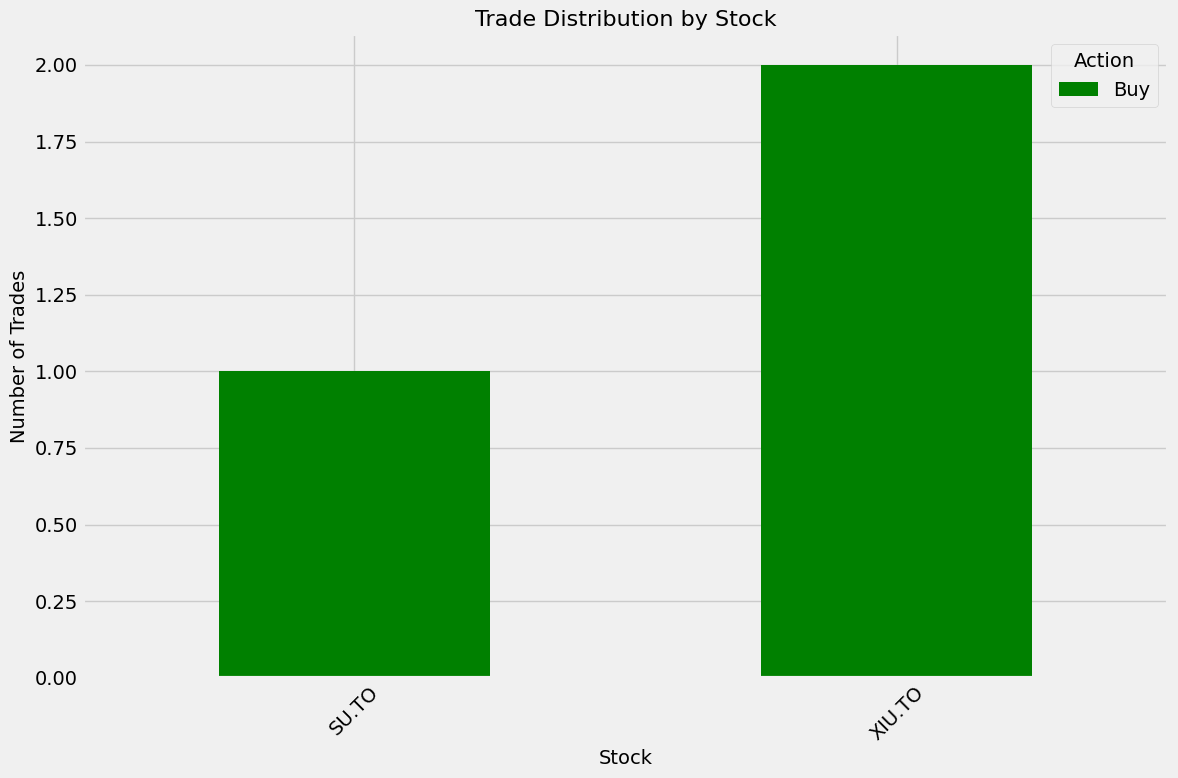

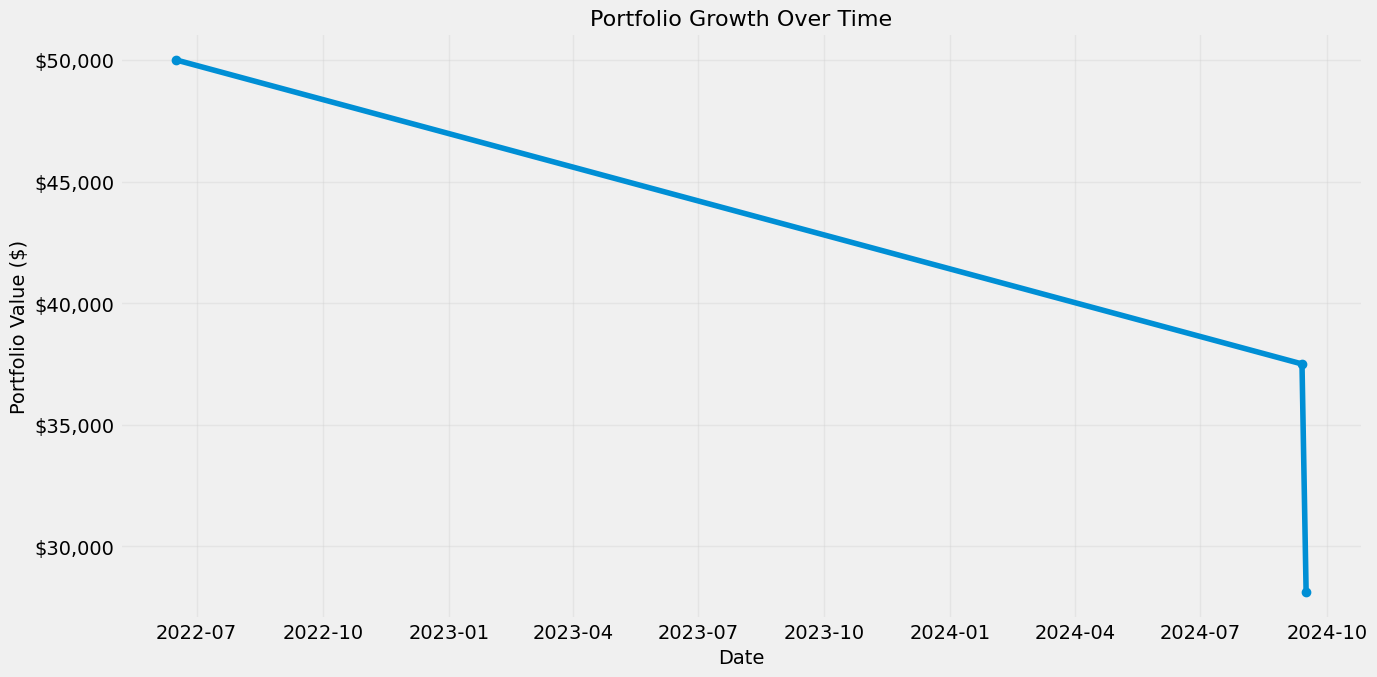

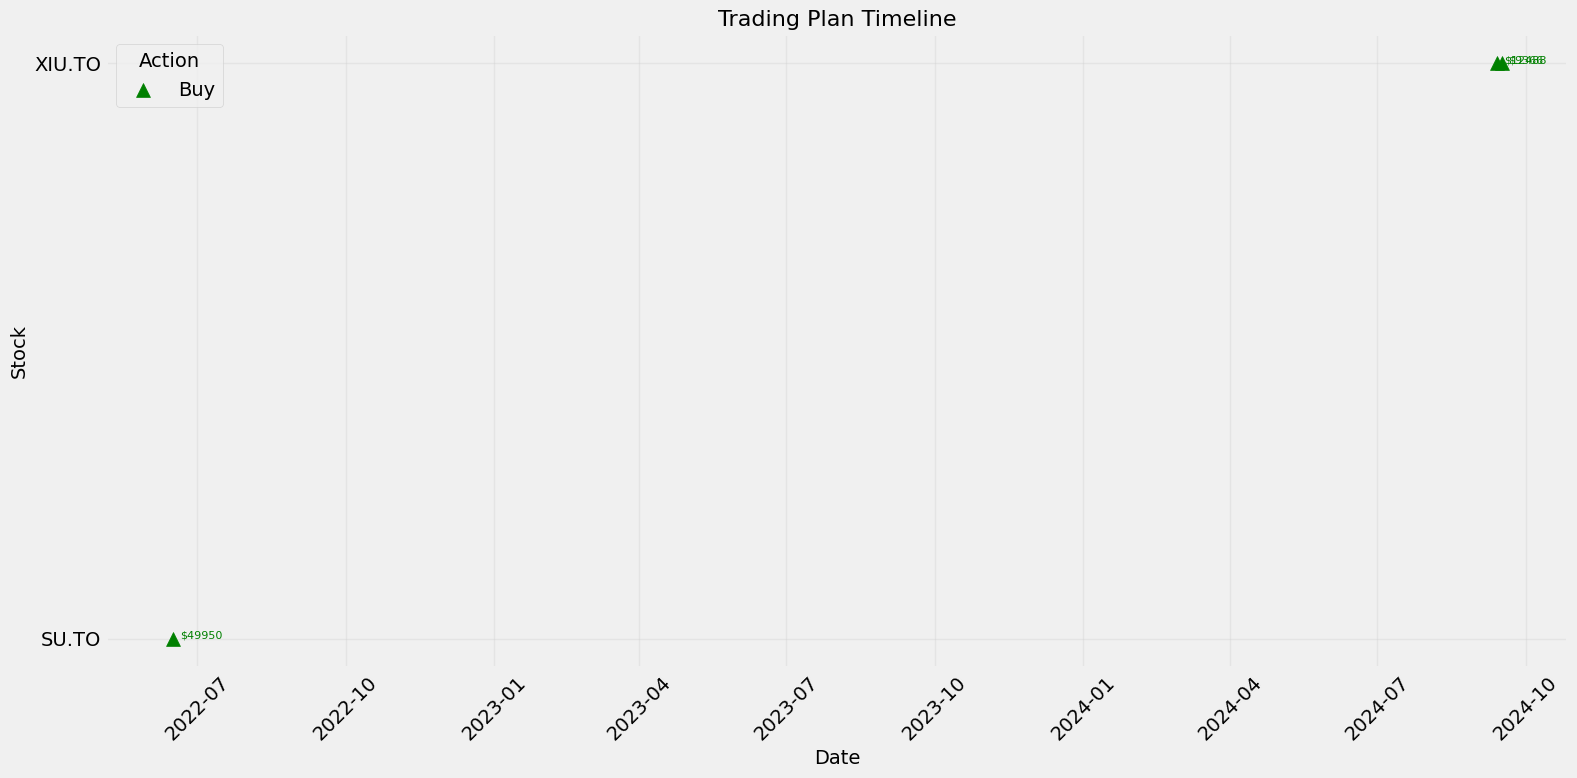

In [ ]:
# Cell 6: Visualize the results
# ---------------------------------------------
# Visualize the trading plan
plot_trade_distribution(trade_history)
plot_portfolio_growth(trade_history)
plot_trading_plan_timeline(trade_history)